In [9]:
import os
import pandas as pd
import json
import tqdm


In [10]:
with open('/projects/structures/peptide_swap_mel5/FLTAIFVVVI/statistics.json', 'r') as file:
    data = json.load(file)


In [11]:
data

{'ranked_0': {'ranking_confidence': 0.8135886337981142,
  'plddt': 92.12117068886212,
  'ptm': 0.8461874259638373,
  'iptm': 0.80543894,
  'tcr-pmhc_iptm': 0.7725619660773986},
 'ranked_1': {'ranking_confidence': 0.8114710786163633,
  'plddt': 91.9645852060079,
  'ptm': 0.844062079101713,
  'iptm': 0.8033233,
  'tcr-pmhc_iptm': 0.7515251890213599},
 'ranked_2': {'ranking_confidence': 0.8075296870999528,
  'plddt': 91.93997296837753,
  'ptm': 0.8414785822893143,
  'iptm': 0.79904246,
  'tcr-pmhc_iptm': 0.7477051941578501},
 'ranked_3': {'ranking_confidence': 0.7926356694220598,
  'plddt': 91.49028296622822,
  'ptm': 0.8292457566256792,
  'iptm': 0.78348315,
  'tcr-pmhc_iptm': 0.7334826230616762},
 'ranked_4': {'ranking_confidence': 0.738837133826492,
  'plddt': 90.5124724949462,
  'ptm': 0.7874893495523816,
  'iptm': 0.7266741,
  'tcr-pmhc_iptm': 0.6513064268045454},
 'tcra_tmplts': ['3hg1_D', '3qeu_A', '6xqp_E', '7n1d_A'],
 'tcrb_tmplts': ['5xov_H', '4jfh_E', '3tf7_C', '3tf7_C'],
 'pmh

In [18]:
structures = os.listdir('/projects/structures/clusters/HLA-A/')

res_dict_a = {}

for structure in tqdm.tqdm(structures):
    
    statistics_path = f'/projects/structures/clusters/HLA-A/{structure}/statistics.json'
    
    if os.path.exists(statistics_path):
        with open(statistics_path, 'r') as statistics:
            statistics = json.load(statistics)
            res_dict_a[structure] = statistics['ranked_0']

100%|██████████| 9436/9436 [08:55<00:00, 17.62it/s]


In [19]:
structures = os.listdir('/projects/structures/clusters/HLA-B/')

res_dict_b = {}

for structure in tqdm.tqdm(structures):
    
    statistics_path = f'/projects/structures/clusters/HLA-B/{structure}/statistics.json'
    
    if os.path.exists(statistics_path):
        with open(statistics_path, 'r') as statistics:
            statistics = json.load(statistics)
            res_dict_b[structure] = statistics['ranked_0']

100%|██████████| 396/396 [00:23<00:00, 16.90it/s]


In [21]:
structures = os.listdir('/projects/structures/clusters/HLA-E/')

res_dict_e = {}

for structure in tqdm.tqdm(structures):
    
    statistics_path = f'/projects/structures/clusters/HLA-E/{structure}/statistics.json'
    
    if os.path.exists(statistics_path):
        with open(statistics_path, 'r') as statistics:
            statistics = json.load(statistics)
            res_dict_e[structure] = statistics['ranked_0']

100%|██████████| 9/9 [00:00<00:00, 13.48it/s]


In [22]:
res_dict_b

{'659af1f70f7be2621cc06993b38175853fceadccfbf58dea7c34c778ba769d8b': {'ranking_confidence': 0.8883501884412368,
  'plddt': 94.77920947969781,
  'ptm': 0.9047269210575022,
  'iptm': 0.884256,
  'tcr-pmhc_iptm': 0.8573981519867878},
 '301b6f62c5845441492814028da7f0944d2d4bd123dc8037d83053e19142016e': {'ranking_confidence': 0.6596649942004851,
  'plddt': 92.07788394076238,
  'ptm': 0.7290138290346522,
  'iptm': 0.6423278,
  'tcr-pmhc_iptm': 0.5055092814261907},
 '6eb1aea5fc816f27d0e5e74291e8818f852ec012c147791983be3e0352c51d71': {'ranking_confidence': 0.7950603625615095,
  'plddt': 92.40895237672711,
  'ptm': 0.833721707979666,
  'iptm': 0.785395,
  'tcr-pmhc_iptm': 0.7243901847148282},
 '584ab9ce5fedbe10d4b1238190c45f1c625c21a432684b45a890ee8fa0be05a0': {'ranking_confidence': 0.7579043744812461,
  'plddt': 93.30105198496732,
  'ptm': 0.8050720089723926,
  'iptm': 0.74611247,
  'tcr-pmhc_iptm': 0.6734902968339764},
 '4283b06809bace9ce9261bf5e903da731a4e2bd7dc6fb833eeea77d869a9d357': {'ran

In [29]:
res_qual = pd.DataFrame(res_dict_e | res_dict_b | res_dict_a).T


res_qual.to_csv('quality_curr_structures.tsv', sep='\t')

In [32]:
contacts = pd.read_csv('contacts_curr_structures.tsv', sep='\t', index_col=0)

contacts.columns = ['num_contacts']


In [35]:
total_data = pd.concat([res_qual, contacts], axis = 1)
total_data

,ranking_confidence,plddt,ptm,iptm,tcr-pmhc_iptm,num_contacts
fb95e51bc7d7e699457002ecb3cbbc9cce7b1628c3785096f3cbb920d41450eb,0.545186,88.507215,0.641245,0.521171,0.379790,8
5c48c8042cd6405830593d72e1ac3498a24a15a3a4d1d6b258d6add7f597f6bd,0.609681,90.394358,0.690247,0.589540,0.399869,13
4c55d51c798c017d37736929b26903c977a070204f97bef91559c9053f997217,0.604793,88.812546,0.683908,0.585014,0.452284,18
b765d2c65831ba7d99fc49145b7291f56e0f8ca8d4f678c2b8b539be95861356,0.730244,90.659333,0.781723,0.717374,0.706096,20
30545cbd3cc0a4290efdbd757c43d9bc20adce5a1a77c17ad27cfda05885b9fb,0.702323,91.617858,0.762058,0.687389,0.560634,17
...,...,...,...,...,...,...
8d758d286487ce18fd3b2b3d23d796aac6d25d0f4ab926bb19c0c0e80e730d2b,0.861143,94.614537,0.885557,0.855039,0.839061,12
c59816afa7843b3ae2093d064da816d743ce973523904f5fd98cff916c92d17c,0.869992,95.124419,0.892402,0.864390,0.840996,19
f4a15f4197af652eb6a3a8f7557d9776305e3856fecf7441fc68db0116e9d236,0.788360,92.823142,0.827428,0.778593,0.689536,18
f78501d4a54031b2a4eacc2b30e8927fea181f42535650ff745ccc1dbe78a251,0.815357,93.252800,0.852147,0.806159,0.765123,22


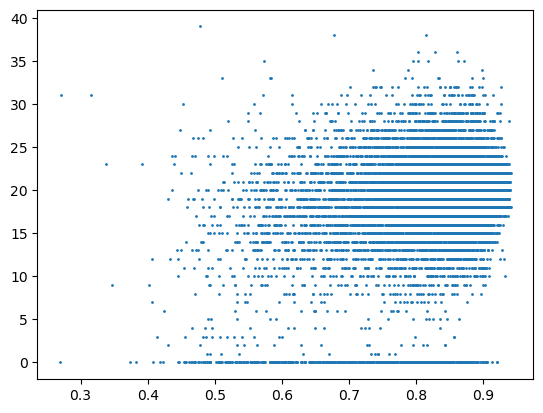

In [38]:
import matplotlib.pyplot as plt

plt.scatter(total_data.ranking_confidence, total_data.num_contacts, s=1)

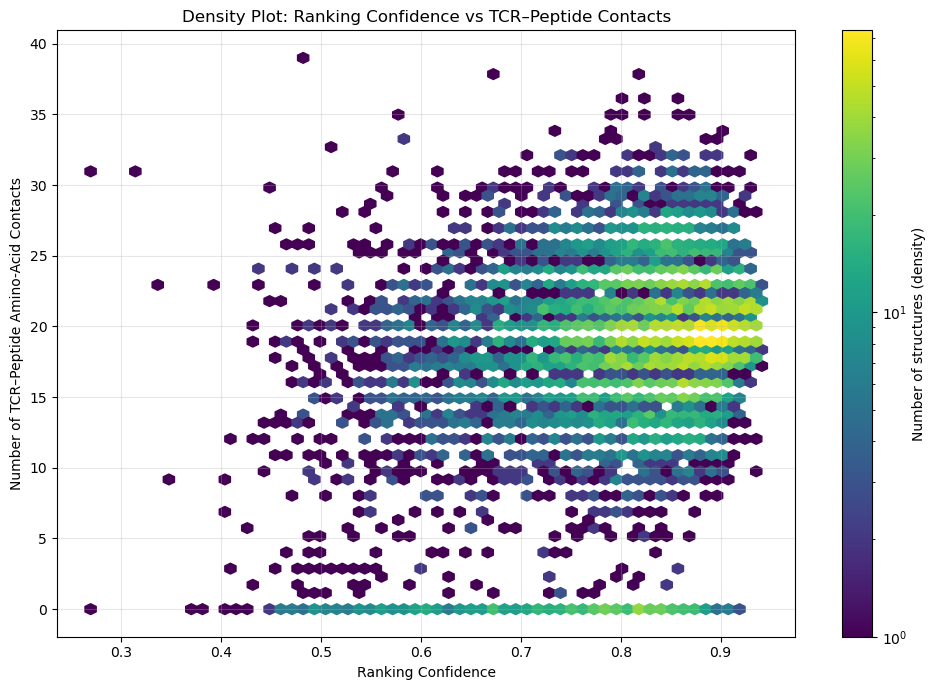

In [39]:
import matplotlib.pyplot as plt

# Assuming total_data is your pandas DataFrame
x = total_data['ranking_confidence']
y = total_data['num_contacts']

plt.figure(figsize=(10, 7))
hb = plt.hexbin(x, y, 
                gridsize=60,           # increase for more detail, decrease for smoother
                cmap='viridis',        # nice density colors (you can try 'plasma', 'magma', 'YlOrRd')
                mincnt=1,              # don't show empty bins
                bins='log')            # logarithmic scale (very useful when density varies a lot)

plt.colorbar(hb, label='Number of structures (density)')
plt.xlabel('Ranking Confidence')
plt.ylabel('Number of TCR–Peptide Amino-Acid Contacts')
plt.title('Density Plot: Ranking Confidence vs TCR–Peptide Contacts')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

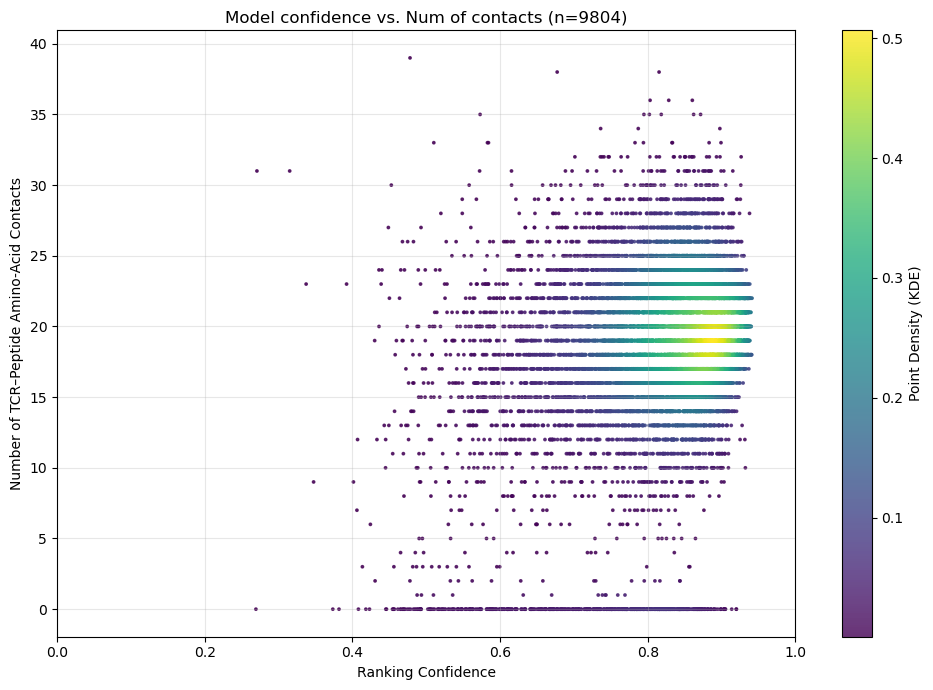

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

x = total_data['ranking_confidence'].values
y = total_data['num_contacts'].values

# Calculate 2D kernel density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(10, 7))
plt.scatter(x, y, c=z, s=3, cmap='viridis', alpha=0.8)   # s=3 or s=1 for tiny points
plt.colorbar(label='Point Density (KDE)')
plt.xlabel('Ranking Confidence')
plt.ylabel('Number of TCR–Peptide Amino-Acid Contacts')
plt.title('Model confidence vs. Num of contacts (n=9804)')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('confidence_vs_contacts.png', dpi=300)
plt.show()

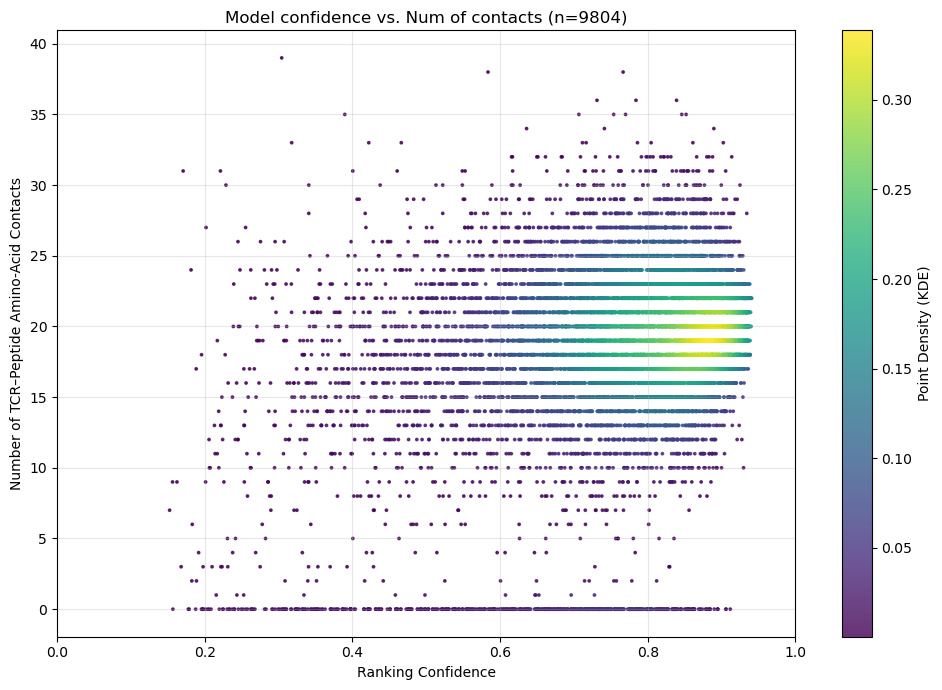

In [46]:
x = total_data['tcr-pmhc_iptm'].values
y = total_data['num_contacts'].values

# Calculate 2D kernel density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(10, 7))
plt.scatter(x, y, c=z, s=3, cmap='viridis', alpha=0.8)   # s=3 or s=1 for tiny points
plt.colorbar(label='Point Density (KDE)')
plt.xlabel('Ranking Confidence')
plt.ylabel('Number of TCR–Peptide Amino-Acid Contacts')
plt.title('Model confidence vs. Num of contacts (n=9804)')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.tight_layout()
#plt.savefig('confidence_vs_contacts.png', dpi=300)
plt.show()

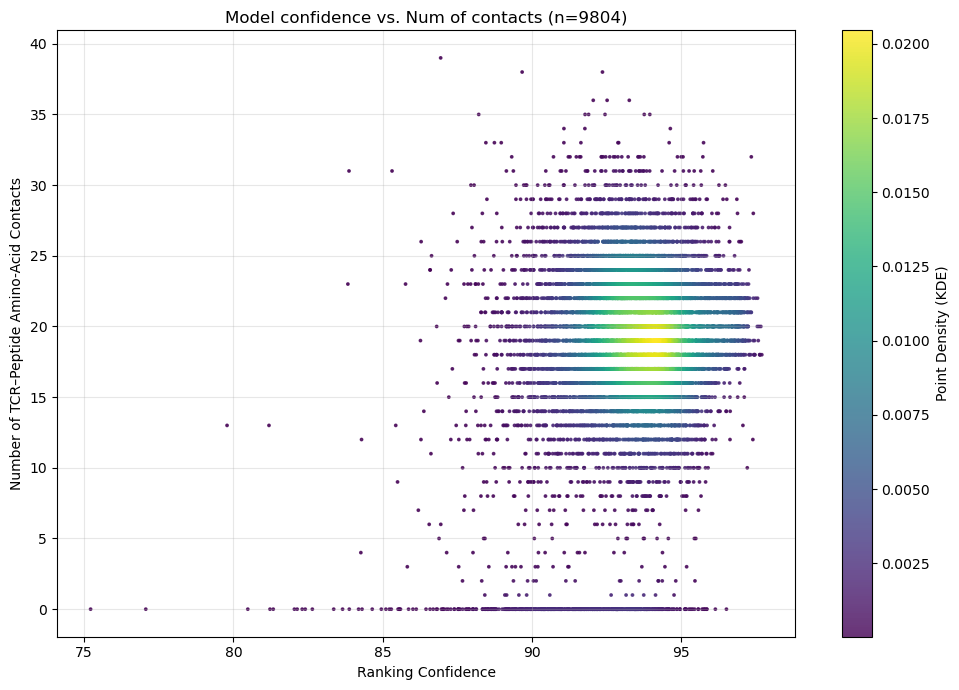

In [48]:
x = total_data['plddt'].values
y = total_data['num_contacts'].values

# Calculate 2D kernel density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(10, 7))
plt.scatter(x, y, c=z, s=3, cmap='viridis', alpha=0.8)   # s=3 or s=1 for tiny points
plt.colorbar(label='Point Density (KDE)')
plt.xlabel('Ranking Confidence')
plt.ylabel('Number of TCR–Peptide Amino-Acid Contacts')
plt.title('Model confidence vs. Num of contacts (n=9804)')
plt.grid(True, alpha=0.3)
#plt.xlim(0, 1)
plt.tight_layout()
#plt.savefig('confidence_vs_contacts.png', dpi=300)
plt.show()

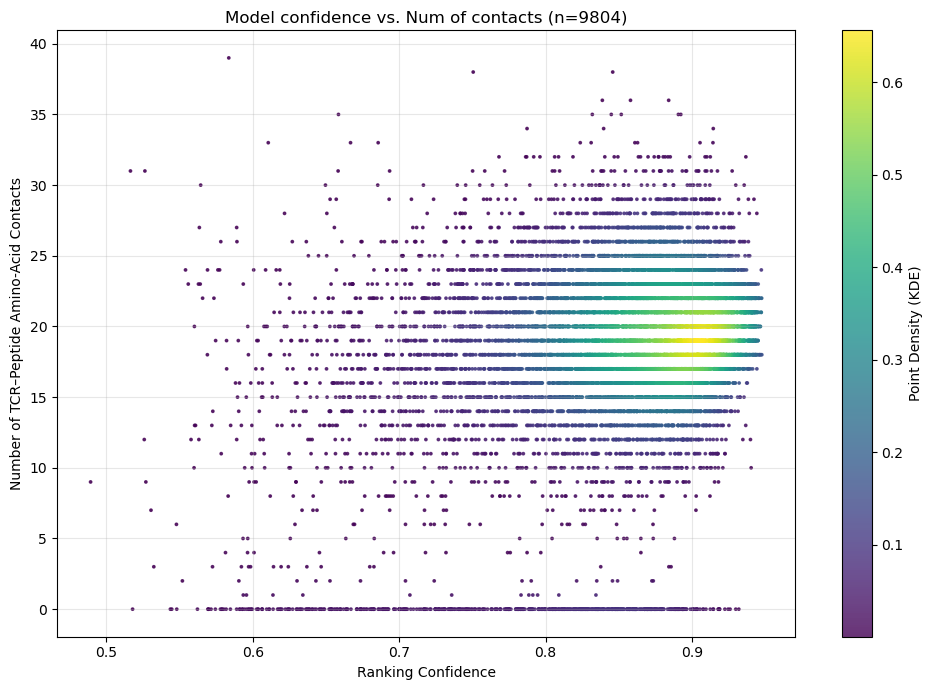

In [49]:
x = total_data['ptm'].values
y = total_data['num_contacts'].values

# Calculate 2D kernel density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(10, 7))
plt.scatter(x, y, c=z, s=3, cmap='viridis', alpha=0.8)   # s=3 or s=1 for tiny points
plt.colorbar(label='Point Density (KDE)')
plt.xlabel('Ranking Confidence')
plt.ylabel('Number of TCR–Peptide Amino-Acid Contacts')
plt.title('Model confidence vs. Num of contacts (n=9804)')
plt.grid(True, alpha=0.3)
#plt.xlim(0, 1)
plt.tight_layout()
#plt.savefig('confidence_vs_contacts.png', dpi=300)
plt.show()